In [18]:
# CELL 1: SETUP & BASIC TRADING STRATEGY
!pip install yfinance pandas numpy matplotlib seaborn plotly scipy -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
print("✅ ALL PACKAGES INSTALLED!")

class Config:
    CRYPTO_SYMBOLS = ['ETH-USD', 'BTC-USD']
    PRIMARY_SYMBOL = 'ETH-USD'
    PERIOD = '60d'
    INTERVAL = '1h'
    INITIAL_CAPITAL = 10000
    RSI_PERIOD = 14
    RSI_OVERSOLD = 30
    RSI_OVERBOUGHT = 70
config = Config()

def fetch_crypto_data_fixed(symbol):
    try:
        print(f"Downloading {symbol}...")
        ticker = yf.Ticker(symbol)
        data = ticker.history(period=config.PERIOD, interval=config.INTERVAL)

        if data.empty:
            return None

        print(f"Columns: {data.columns.tolist()}")

        # Calculate indicators
        data['SMA_20'] = data['Close'].rolling(window=20).mean()

        # RSI calculation
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))

        # Bollinger Bands
        data['BB_Middle'] = data['Close'].rolling(window=20).mean()
        bb_std = data['Close'].rolling(window=20).std()
        data['BB_Upper'] = data['BB_Middle'] + (bb_std * 2)
        data['BB_Lower'] = data['BB_Middle'] - (bb_std * 2)

        # MACD
        ema_12 = data['Close'].ewm(span=12).mean()
        ema_26 = data['Close'].ewm(span=26).mean()
        data['MACD'] = ema_12 - ema_26
        data['MACD_Signal'] = data['MACD'].ewm(span=9).mean()

        # Daily Return
        data['Daily_Return'] = data['Close'].pct_change()

        data = data.fillna(method='bfill').fillna(method='ffill')
        print(f"✅ {symbol}: {len(data)} records with columns: {data.columns.tolist()}")
        return data
    except Exception as e:
        print(f"❌ Error with {symbol}: {e}")
        import traceback
        traceback.print_exc()
        return None

# Fetch data
print("🔄 Fetching crypto data...")
crypto_data = {}
for symbol in config.CRYPTO_SYMBOLS:
    data = fetch_crypto_data_fixed(symbol)
    if data is not None:
        crypto_data[symbol] = data

if crypto_data:
    primary_data = crypto_data[config.PRIMARY_SYMBOL]
    print(f"\n📊 DATA SUMMARY:")
    print(f"Symbol: {config.PRIMARY_SYMBOL}")
    print(f"Records: {len(primary_data)}")
    print(f"Current Price: ${primary_data['Close'].iloc[-1]:.2f}")
    print(f"Current RSI: {primary_data['RSI'].iloc[-1]:.1f}")
else:
    print("❌ No data available")

class TradingStrategy:
    def __init__(self, initial_capital=10000):
        self.initial_capital = initial_capital

    def backtest_strategy(self, data):
        cash = self.initial_capital
        position = 0
        portfolio_history = []
        trades = []
        prices = data['Close'].values
        rsi_values = data['RSI'].values
        dates = data.index

        for i in range(len(prices)):
            current_price = float(prices[i])
            current_rsi = float(rsi_values[i])
            current_date = dates[i]

            if current_rsi < 30 and position == 0 and cash > 0:
                position = cash / current_price
                cash = 0
                trades.append({'timestamp': current_date, 'action': 'BUY', 'price': current_price, 'quantity': position})
            elif current_rsi > 70 and position > 0:
                cash = position * current_price
                trades.append({'timestamp': current_date, 'action': 'SELL', 'price': current_price, 'quantity': position})
                position = 0

            portfolio_value = cash + (position * current_price)
            portfolio_history.append({'timestamp': current_date, 'portfolio_value': portfolio_value, 'price': current_price})

        if position > 0:
            final_price = float(prices[-1])
            cash = position * final_price
            trades.append({'timestamp': dates[-1], 'action': 'SELL', 'price': final_price, 'quantity': position})
            position = 0

        return pd.DataFrame(portfolio_history), pd.DataFrame(trades), data

def calculate_performance(portfolio_df, trades_df, price_data):
    initial_value = config.INITIAL_CAPITAL
    final_value = portfolio_df['portfolio_value'].iloc[-1]
    total_return = (final_value - initial_value) / initial_value
    buy_hold_return = (price_data['Close'].iloc[-1] - price_data['Close'].iloc[0]) / price_data['Close'].iloc[0]
    portfolio_df['Daily_Return'] = portfolio_df['portfolio_value'].pct_change()
    volatility = portfolio_df['Daily_Return'].std() * np.sqrt(365*24) if len(portfolio_df) > 1 else 0
    portfolio_df['Peak'] = portfolio_df['portfolio_value'].cummax()
    portfolio_df['Drawdown'] = (portfolio_df['portfolio_value'] - portfolio_df['Peak']) / portfolio_df['Peak']
    max_drawdown = portfolio_df['Drawdown'].min() if len(portfolio_df) > 1 else 0

    metrics = {
        'initial_capital': initial_value, 'final_value': final_value,
        'total_return_pct': total_return * 100, 'buy_hold_return_pct': buy_hold_return * 100,
        'excess_return_pct': (total_return - buy_hold_return) * 100, 'volatility': volatility,
        'max_drawdown_pct': max_drawdown * 100, 'total_trades': len(trades_df)
    }
    return metrics

def print_performance_report(metrics):
    print("\n" + "="*50)
    print("📊 PERFORMANCE REPORT")
    print("="*50)
    print(f"Initial Capital: ${metrics['initial_capital']:,.2f}")
    print(f"Final Portfolio Value: ${metrics['final_value']:,.2f}")
    print(f"Total Return: {metrics['total_return_pct']:+.2f}%")
    print(f"Buy & Hold Return: {metrics['buy_hold_return_pct']:+.2f}%")
    print(f"Excess Return: {metrics['excess_return_pct']:+.2f}%")
    print(f"Volatility: {metrics['volatility']:.4f}")
    print(f"Max Drawdown: {metrics['max_drawdown_pct']:.2f}%")
    print(f"Total Trades: {metrics['total_trades']}")
    print("="*50)

# Run basic backtest
if crypto_data:
    print("🔧 RUNNING RSI STRATEGY BACKTEST...")
    try:
        strategy = TradingStrategy(initial_capital=config.INITIAL_CAPITAL)
        portfolio_df, trades_df, strategy_data = strategy.backtest_strategy(primary_data)
        metrics = calculate_performance(portfolio_df, trades_df, primary_data)
        print_performance_report(metrics)

        if not trades_df.empty:
            print(f"\n📋 TRADE LOG:")
            print("-" * 50)
            for _, trade in trades_df.iterrows():
                action_icon = "🟢 BUY" if trade['action'] == 'BUY' else "🔴 SELL"
                print(f"{action_icon} | {trade['timestamp'].strftime('%Y-%m-%d %H:%M')} | ${trade['price']:.2f}")
            print(f"Total Trades: {len(trades_df)}")
        else:
            print("\n📋 No trades executed during this period")

    except Exception as e:
        print(f"❌ Error during backtesting: {e}")

print("✅ CELL 1 COMPLETED - BASIC STRATEGY READY!")

✅ ALL PACKAGES INSTALLED!
🔄 Fetching crypto data...
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
✅ ETH-USD: 1408 records with columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'SMA_20', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'MACD', 'MACD_Signal', 'Daily_Return']
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
✅ BTC-USD: 1408 records with columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'SMA_20', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'MACD', 'MACD_Signal', 'Daily_Return']

📊 DATA SUMMARY:
Symbol: ETH-USD
Records: 1408
Current Price: $2132.47
Current RSI: 57.6
🔧 RUNNING RSI STRATEGY BACKTEST...

📊 PERFORMANCE REPORT
Initial Capital: $10,000.00
Final Portfolio Value: $11,566.12
Total Return: +15.66%
Buy & Hold Return: -0.96%
Excess Return: +16.62%
Volatility: 0.3454
Max Drawdown: -8.17%
Total Trades: 36

📋 TRADE LOG:
------------------------------

📈 GENERATING ANALYSIS CHARTS...
1. Technical Analysis Chart...


2. Strategy Performance Chart...


3. Drawdown Analysis...


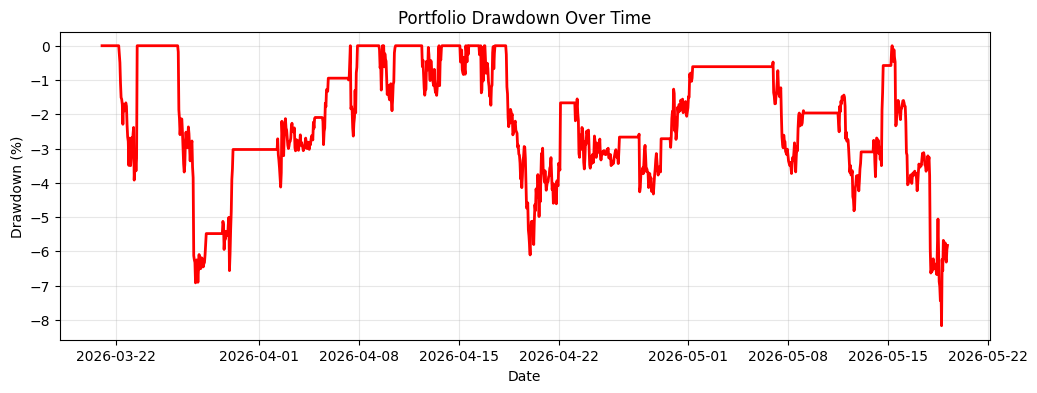

🔗 ANALYZING CRYPTO CORRELATIONS...


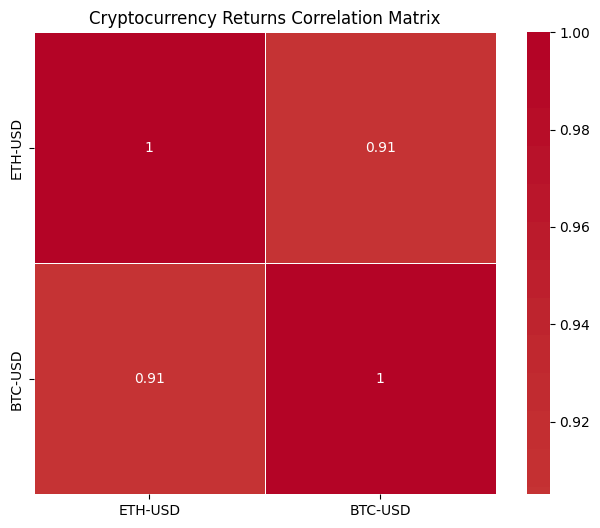

📊 Correlation Matrix:
         ETH-USD  BTC-USD
ETH-USD    1.000    0.905
BTC-USD    0.905    1.000
📡 CURRENT MARKET ANALYSIS

💡 CURRENT SIGNALS FOR ETH-USD:
----------------------------------------
🟡 RSI (57.6): NEUTRAL
🟢 MACD: BULLISH
🟢 Price: ABOVE SMA20 (+0.6%)
----------------------------------------
🎯 OVERALL: BULLISH BIAS - Consider BUY opportunities
✅ CELL 2 COMPLETED - VISUALIZATIONS & ANALYSIS READY!


In [19]:
# CELL 2: VISUALIZATION & ANALYSIS

def plot_technical_analysis(data, title="Technical Analysis"):
    fig = make_subplots(rows=3, cols=1, subplot_titles=['Price & Bollinger Bands', 'RSI', 'MACD'],
    vertical_spacing=0.08, row_heights=[0.5, 0.25, 0.25])
    fig.add_trace(go.Scatter(x=data.index, y=data['Close'], name='Price', line=dict(color='blue')), row=1, col=1)
    fig.add_trace(go.Scatter(x=data.index, y=data['BB_Upper'], name='BB Upper', line=dict(color='red', dash='dash')), row=1, col=1)
    fig.add_trace(go.Scatter(x=data.index, y=data['BB_Lower'], name='BB Lower', line=dict(color='green', dash='dash')), row=1, col=1)
    fig.add_trace(go.Scatter(x=data.index, y=data['RSI'], name='RSI', line=dict(color='purple')), row=2, col=1)
    fig.add_hline(y=70, line_dash="dash", line_color="red", row=2, col=1)
    fig.add_hline(y=30, line_dash="dash", line_color="green", row=2, col=1)
    fig.add_hline(y=50, line_dash="dot", line_color="gray", row=2, col=1)
    fig.add_trace(go.Scatter(x=data.index, y=data['MACD'], name='MACD', line=dict(color='orange')), row=3, col=1)
    fig.add_trace(go.Scatter(x=data.index, y=data['MACD_Signal'], name='Signal', line=dict(color='red')), row=3, col=1)
    fig.update_layout(height=800, title_text=title)
    fig.show()

def plot_strategy_performance(portfolio_df, trades, price_data):
    fig = make_subplots(rows=2, cols=1, subplot_titles=['Price with Trade Signals', 'Portfolio Performance'], vertical_spacing=0.1)
    fig.add_trace(go.Scatter(x=price_data.index, y=price_data['Close'], name='Price', line=dict(color='blue')), row=1, col=1)
    if not trades.empty:
        buy_trades = trades[trades['action'] == 'BUY']
        sell_trades = trades[trades['action'] == 'SELL']
        fig.add_trace(go.Scatter(x=buy_trades['timestamp'], y=buy_trades['price'], mode='markers', name='BUY',
                               marker=dict(color='green', size=10, symbol='triangle-up')), row=1, col=1)
        fig.add_trace(go.Scatter(x=sell_trades['timestamp'], y=sell_trades['price'], mode='markers', name='SELL',
                               marker=dict(color='red', size=10, symbol='triangle-down')), row=1, col=1)
    fig.add_trace(go.Scatter(x=portfolio_df['timestamp'], y=portfolio_df['portfolio_value'], name='Strategy', line=dict(color='green')), row=2, col=1)
    initial_value = portfolio_df['portfolio_value'].iloc[0]
    buy_hold_value = initial_value * (price_data['Close'] / price_data['Close'].iloc[0])
    fig.add_trace(go.Scatter(x=price_data.index, y=buy_hold_value, name='Buy & Hold', line=dict(color='orange', dash='dash')), row=2, col=1)
    fig.update_layout(height=700, title_text='Trading Strategy Performance')
    fig.show()

# Generate visualizations
print("📈 GENERATING ANALYSIS CHARTS...")

if 'primary_data' in locals() and 'portfolio_df' in locals():
    # 1. Technical Analysis Chart
    print("1. Technical Analysis Chart...")
    plot_technical_analysis(primary_data, f"{config.PRIMARY_SYMBOL} Technical Analysis")

    # 2. Strategy Performance Chart
    print("2. Strategy Performance Chart...")
    plot_strategy_performance(portfolio_df, trades_df, primary_data)

    # 3. Drawdown Analysis
    print("3. Drawdown Analysis...")
    plt.figure(figsize=(12, 4))
    plt.plot(portfolio_df['timestamp'], portfolio_df['Drawdown'] * 100, color='red', linewidth=2)
    plt.title('Portfolio Drawdown Over Time')
    plt.ylabel('Drawdown (%)')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("❌ No data available for visualization")

# Correlation Analysis
print("🔗 ANALYZING CRYPTO CORRELATIONS...")

if len(crypto_data) > 1:
    returns_data = {}
    for symbol, data in crypto_data.items():
        returns_data[symbol] = data['Daily_Return'].dropna()

    returns_df = pd.DataFrame(returns_data)
    correlation_matrix = returns_df.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Cryptocurrency Returns Correlation Matrix')
    plt.show()

    print("📊 Correlation Matrix:")
    print(correlation_matrix.round(3))
else:
    print("ℹ️ Need at least 2 cryptocurrencies for correlation analysis")

# Current Market Analysis
print("📡 CURRENT MARKET ANALYSIS")

if 'primary_data' in locals():
    current_data = primary_data.iloc[-1]

    print(f"\n💡 CURRENT SIGNALS FOR {config.PRIMARY_SYMBOL}:")
    print("-" * 40)

    # RSI Analysis
    rsi = current_data['RSI']
    if rsi < 30:
        rsi_signal = "STRONG BUY (Oversold)"
        rsi_color = "🟢"
    elif rsi > 70:
        rsi_signal = "STRONG SELL (Overbought)"
        rsi_color = "🔴"
    else:
        rsi_signal = "NEUTRAL"
        rsi_color = "🟡"

    print(f"{rsi_color} RSI ({rsi:.1f}): {rsi_signal}")

    # MACD Analysis
    macd = current_data['MACD']
    macd_signal = current_data['MACD_Signal']
    if macd > macd_signal:
        macd_signal_text = "BULLISH"
        macd_color = "🟢"
    else:
        macd_signal_text = "BEARISH"
        macd_color = "🔴"

    print(f"{macd_color} MACD: {macd_signal_text}")

    # Price vs SMA
    price_vs_sma = (current_data['Close'] - current_data['SMA_20']) / current_data['SMA_20'] * 100
    if price_vs_sma > 0:
        sma_signal = "ABOVE SMA20"
        sma_color = "🟢"
    else:
        sma_signal = "BELOW SMA20"
        sma_color = "🔴"

    print(f"{sma_color} Price: {sma_signal} ({price_vs_sma:+.1f}%)")

    print("-" * 40)

    # Summary
    buy_signals = sum([1 for signal in [rsi_signal, macd_signal_text, sma_signal] if 'BUY' in signal or 'BULL' in signal or 'ABOVE' in signal])

    if buy_signals >= 2:
        print("🎯 OVERALL: BULLISH BIAS - Consider BUY opportunities")
    elif buy_signals <= 1:
        print("🎯 OVERALL: BEARISH BIAS - Consider SELL opportunities")
    else:
        print("🎯 OVERALL: NEUTRAL - Wait for clearer signals")

print("✅ CELL 2 COMPLETED - VISUALIZATIONS & ANALYSIS READY!")

In [20]:
# CELL 3: ADVANCED SMC/ICT STRATEGY
print("🔔 UPGRADING TO ADVANCED TRADING STRATEGY WITH SMC/ICT...")

import smtplib
from email.mime.text import MIMEText
import email.mime.multipart # Changed import statement
import time
from datetime import datetime
import pytz

class AdvancedTradingStrategy:
    def __init__(self):
        self.last_alert_time = None
        self.alert_cooldown = 3600
        # ✅ Set India Time Zone
        self.india_tz = pytz.timezone('Asia/Kolkata')
        # ✅ GMAIL APP PASSWORD
        self.sender_password_1 = "fayp wepc qqlw qjlc"  # 🔑 Shivam's password

        # 🔥 ADVANCED SMC/ICT PARAMETERS
        self.liquidity_sweep_threshold = 0.018
        self.order_block_lookback = 8
        self.ob_consolidation_threshold = 0.015
        self.volume_spike_multiplier = 1.8

    def get_india_time(self):
        """Get current time in India Kolkata timezone"""
        return datetime.now(self.india_tz)

    def format_india_time(self, dt=None):
        """Format datetime to Indian time format"""
        if dt is None:
            dt = self.get_india_time()
        return dt.strftime('%Y-%m-%d %H:%M:%S IST')

    # 🔥 ADVANCED SMC/ICT METHODS

    def detect_liquidity_sweeps(self, high, low, close, volume):
        """Detect institutional liquidity sweeps"""
        sweeps = []
        for i in range(3, len(high)-1):
            recent_high = max(high[i-3:i])
            recent_low = min(low[i-3:i])

            # Bullish sweep
            if (low[i] < recent_low * (1 - self.liquidity_sweep_threshold) and
                close[i] > ((high[i] + low[i]) / 2) and
                close[i+1] > close[i] and
                volume[i] > np.mean(volume[i-5:i]) * 1.2):
                sweeps.append({'index': i, 'type': 'BULLISH_SWEEP', 'strength': 'HIGH' if volume[i] > np.mean(volume[i-10:i]) * 1.5 else 'MEDIUM'})

            # Bearish sweep
            elif (high[i] > recent_high * (1 + self.liquidity_sweep_threshold) and
                  close[i] < ((high[i] + low[i]) / 2) and
                  close[i+1] < close[i] and
                  volume[i] > np.mean(volume[i-5:i]) * 1.2):
                sweeps.append({'index': i, 'type': 'BEARISH_SWEEP', 'strength': 'HIGH' if volume[i] > np.mean(volume[i-10:i]) * 1.5 else 'MEDIUM'})
        return sweeps

    def identify_order_blocks(self, open_price, high, low, close, volume):
        """Identify Smart Money Order Blocks"""
        order_blocks = []
        for i in range(self.order_block_lookback, len(close)):
            lookback_high = max(high[i-self.order_block_lookback:i])
            lookback_low = min(low[i-self.order_block_lookback:i])
            consolidation_range = (lookback_high - lookback_low) / lookback_low

            if consolidation_range < self.ob_consolidation_threshold:
                current_volume = volume[i]
                avg_volume = np.mean(volume[i-5:i])

                # Bullish OB
                if (close[i] > lookback_high and
                    current_volume > avg_volume * self.volume_spike_multiplier and
                    close[i] > open_price[i]):
                    order_blocks.append({'index': i, 'type': 'BULLISH_OB', 'strength': 'STRONG' if current_volume > avg_volume * 2 else 'MODERATE'})

                # Bearish OB
                elif (close[i] < lookback_low and
                      current_volume > avg_volume * self.volume_spike_multiplier and
                      close[i] < open_price[i]):
                    order_blocks.append({'index': i, 'type': 'BEARISH_OB', 'strength': 'STRONG' if current_volume > avg_volume * 2 else 'MODERATE'})
        return order_blocks

    def calculate_market_structure(self, high, low, close):
        """Determine market structure using Higher Highs/Lower Lows"""
        structure = []
        for i in range(2, len(close)-2):
            # Check for Higher High (HH) and Higher Low (HL) - Uptrend
            if (high[i] > high[i-2] and low[i] > low[i-2] and
                high[i+1] > high[i-1] and low[i+1] > low[i-1]):
                structure.append({'index': i, 'type': 'BULLISH_STRUCTURE', 'trend': 'UPTREND'})

            # Check for Lower High (LH) and Lower Low (LL) - Downtrend
            elif (high[i] < high[i-2] and low[i] < low[i-2] and
                  high[i+1] < high[i-1] and low[i+1] < low[i-1]):
                structure.append({'index': i, 'type': 'BEARISH_STRUCTURE', 'trend': 'DOWNTREND'})

            # Market Structure Break
            elif (high[i] > max(high[i-3:i]) and close[i] < close[i-1]):
                structure.append({'index': i, 'type': 'STRUCTURE_BREAK_BEARISH', 'trend': 'REVERSAL'})
            elif (low[i] < min(low[i-3:i]) and close[i] > close[i-1]):
                structure.append({'index': i, 'type': 'STRUCTURE_BREAK_BULLISH', 'trend': 'REVERSAL'})

        return structure

    def get_enhanced_signals(self, data):
        """Combine Traditional RSI with Advanced SMC/ICT concepts"""
        if data is None or len(data) < 20:
            return None

        # Extract price data
        high = data['High'].values
        low = data['Low'].values
        close = data['Close'].values
        open_price = data['Open'].values
        volume = data['Volume'].values

        # Get RSI values
        rsi_values = data['RSI'].values

        # Get advanced SMC signals
        liquidity_sweeps = self.detect_liquidity_sweeps(high, low, close, volume)
        order_blocks = self.identify_order_blocks(open_price, high, low, close, volume)
        market_structure = self.calculate_market_structure(high, low, close)

        current_index = len(close) - 1
        current_rsi = rsi_values[current_index]
        current_price = close[current_index]
        current_time = data.index[current_index]

        # Convert to India time if needed
        if hasattr(current_time, 'tz'):
            if current_time.tz is None:
                current_time = pytz.UTC.localize(current_time)
            current_time_ist = current_time.astimezone(self.india_tz)
        else:
            current_time_ist = current_time

        signals = []
        confidence_score = 0

        # 🔥 CORE RSI SIGNAL (40 points)
        if current_rsi < config.RSI_OVERSOLD:
            base_signal = {
                'type': 'BUY',
                'strength': 'RSI_OVERSOLD',
                'message': f"RSI {current_rsi:.1f} - OVERSOLD",
                'price': current_price,
                'rsi': current_rsi,
                'timestamp': current_time_ist,
                'confidence': 40
            }
            signals.append(base_signal)
            confidence_score += 40

        elif current_rsi > config.RSI_OVERBOUGHT:
            base_signal = {
                'type': 'SELL',
                'strength': 'RSI_OVERBOUGHT',
                'message': f"RSI {current_rsi:.1f} - OVERBOUGHT",
                'price': current_price,
                'rsi': current_rsi,
                'timestamp': current_time_ist,
                'confidence': 40
            }
            signals.append(base_signal)
            confidence_score += 40

        # 🔥 SMC/ICT CONFIRMATIONS (60 points available)

        # 1. Liquidity Sweep Confirmation (20 points)
        recent_sweeps = [s for s in liquidity_sweeps if s['index'] >= current_index - 3]
        for sweep in recent_sweeps:
            if sweep['type'] == 'BULLISH_SWEEP' and any(s['type'] == 'BUY' for s in signals):
                signals.append({
                    'type': 'BUY',
                    'strength': 'LIQUIDITY_SWEEP_CONFIRMATION',
                    'message': f"Bullish Liquidity Sweep detected (Strength: {sweep['strength']})",
                    'price': current_price,
                    'rsi': current_rsi,
                    'timestamp': current_time_ist,
                    'confidence': 20
                })
                confidence_score += 20
                break
            elif sweep['type'] == 'BEARISH_SWEEP' and any(s['type'] == 'SELL' for s in signals):
                signals.append({
                    'type': 'SELL',
                    'strength': 'LIQUIDITY_SWEEP_CONFIRMATION',
                    'message': f"Bearish Liquidity Sweep detected (Strength: {sweep['strength']})",
                    'price': current_price,
                    'rsi': current_rsi,
                    'timestamp': current_time_ist,
                    'confidence': 20
                })
                confidence_score += 20
                break

        # 2. Order Block Confirmation (20 points)
        recent_obs = [ob for ob in order_blocks if ob['index'] >= current_index - 5]
        for ob in recent_obs:
            if ob['type'] == 'BULLISH_OB' and any(s['type'] == 'BUY' for s in signals):
                signals.append({
                    'type': 'BUY',
                    'strength': 'ORDER_BLOCK_CONFIRMATION',
                    'message': f"Bullish Order Block confirmed (Strength: {ob['strength']})",
                    'price': current_price,
                    'rsi': current_rsi,
                    'timestamp': current_time_ist,
                    'confidence': 20
                })
                confidence_score += 20
                break
            elif ob['type'] == 'BEARISH_OB' and any(s['type'] == 'SELL' for s in signals):
                signals.append({
                    'type': 'SELL',
                    'strength': 'ORDER_BLOCK_CONFIRMATION',
                    'message': f"Bearish Order Block confirmed (Strength: {ob['strength']})",
                    'price': current_price,
                    'rsi': current_rsi,
                    'timestamp': current_time_ist,
                    'confidence': 20
                })
                confidence_score += 20
                break

        # 3. Market Structure Confirmation (20 points)
        recent_structure = [ms for ms in market_structure if ms['index'] >= current_index - 2]
        for structure in recent_structure:
            if structure['type'] in ['BULLISH_STRUCTURE', 'STRUCTURE_BREAK_BULLISH'] and any(s['type'] == 'BUY' for s in signals):
                signals.append({
                    'type': 'BUY',
                    'strength': 'MARKET_STRUCTURE_CONFIRMATION',
                    'message': f"Market Structure: {structure['trend']}",
                    'price': current_price,
                    'rsi': current_rsi,
                    'timestamp': current_time_ist,
                    'confidence': 20
                })
                confidence_score += 20
                break
            elif structure['type'] in ['BEARISH_STRUCTURE', 'STRUCTURE_BREAK_BEARISH'] and any(s['type'] == 'SELL' for s in signals):
                signals.append({
                    'type': 'SELL',
                    'strength': 'MARKET_STRUCTURE_CONFIRMATION',
                    'message': f"Market Structure: {structure['trend']}",
                    'price': current_price,
                    'rsi': current_rsi,
                    'timestamp': current_time_ist,
                    'confidence': 20
                })
                confidence_score += 20
                break

        # Determine final signal strength
        if signals:
            main_signal = signals[0]  # First signal is the base RSI signal
            if confidence_score >= 80:
                main_signal['final_strength'] = 'VERY_HIGH_CONFIDENCE'
                main_signal['action'] = 'STRONG_' + main_signal['type']
            elif confidence_score >= 60:
                main_signal['final_strength'] = 'HIGH_CONFIDENCE'
                main_signal['action'] = 'MODERATE_' + main_signal['type']
            elif confidence_score >= 40:
                main_signal['final_strength'] = 'MEDIUM_CONFIDENCE'
                main_signal['action'] = 'BASIC_' + main_signal['type']

            main_signal['confidence_score'] = confidence_score
            main_signal['total_confirmations'] = len([s for s in signals if 'CONFIRMATION' in s['strength']])

        return signals if signals else None

    def send_email_alert(self, subject, message):
        """Send email alert using Gmail account"""
        current_time_ist = self.format_india_time()

        receiver_emails = ["singhshivams1986@gmail.com"]
        sender_email = "singhshivams1986@gmail.com"

        # Try sending from Shivam's account
        try:
            print(f"📧 Attempting to send email from {sender_email}...")

            msg = email.mime.multipart.MIMEMultipart() # Changed usage here
            msg['From'] = sender_email
            msg['To'] = ", ".join(receiver_emails)
            msg['Subject'] = f"🚨 ADVANCED TRADE ALERT: {subject}"

            body = f"""
            ⚡ ADVANCED CRYPTO TRADING ALERT ⚡
            {'='*60}

            {message}

            📊 Alert Time: {current_time_ist}
            🌏 Time Zone: India (Kolkata) - IST
            🎯 Strategy: RSI + SMC/ICT Enhanced
            🔗 Generated by Advanced Crypto Trading Bot

            💰 Higher Accuracy with Smart Money Concepts!
            {'='*60}
            """

            msg.attach(MIMEText(body, 'plain'))

            server = smtplib.SMTP('smtp.gmail.com', 587)
            server.starttls()
            server.login(sender_email, self.sender_password_1)
            text = msg.as_string()
            server.sendmail(sender_email, receiver_emails, text)
            server.quit()

            print(f"✅ Email alert sent from {sender_email}")
            return True

        except Exception as e:
            print(f"❌ Failed to send from {sender_email}: {e}")
            return False

    def should_send_alert(self):
        """Prevent too frequent alerts"""
        if self.last_alert_time is None:
            return True
        time_diff = (self.get_india_time() - self.last_alert_time).total_seconds()
        return time_diff > self.alert_cooldown

    def automate_trade_alerts(self, data, symbol):
        """Main automation function with advanced signal detection"""
        if not self.should_send_alert():
            return

        signals = self.get_enhanced_signals(data)

        if signals:
            current_time_ist = self.format_india_time()
            main_signal = signals[0]

            print(f"\n🎯 ADVANCED TRADE SIGNALS DETECTED FOR {symbol} at {current_time_ist}:")
            print("=" * 70)
            print(f"🏆 MAIN SIGNAL: {main_signal['action']}")
            print(f"📊 Confidence Score: {main_signal['confidence_score']}/100")
            print(f"✅ Confirmations: {main_signal['total_confirmations']} SMC patterns")
            print("-" * 70)

            for signal in signals:
                emoji = "🟢" if signal['type'] == 'BUY' else "🔴"
                strength_icon = "🔥" if 'STRONG' in signal.get('action', '') else "⚡" if 'MODERATE' in signal.get('action', '') else "📈"
                print(f"{emoji} {strength_icon} {signal['strength']}: {signal['message']}")

            print("-" * 70)
            print(f"💰 Current Price: ${main_signal['price']:.2f}")
            print(f"📈 RSI: {main_signal['rsi']:.1f}")

            # Send advanced email alert
            subject = f"{main_signal['action']} - {symbol} - Confidence: {main_signal['confidence_score']}%"
            message = f"""
            🚀 ADVANCED TRADING SIGNAL DETECTED!

            Symbol: {symbol}
            Signal Type: {main_signal['action']}
            Confidence Level: {main_signal['confidence_score']}%
            Confirmations: {main_signal['total_confirmations']} SMC Patterns

            Current Price: ${main_signal['price']:.2f}
            RSI: {main_signal['rsi']:.1f}
            Time: {main_signal['timestamp'].strftime('%Y-%m-%d %H:%M:%S IST')}

            🎯 SIGNAL BREAKDOWN:
            {chr(10).join([f"• {s['message']} (Confidence: +{s['confidence']})" for s in signals])}

            📈 Trading Strategy: RSI + SMC/ICT Enhanced
            💡 Smart Money Concepts Used:
               • Liquidity Sweeps
               • Order Blocks
               • Market Structure
               • RSI Momentum

            🔔 This high-confidence alert was sent to:
               • singhshivams1986@gmail.com

            🌏 Time Zone: India Standard Time (Kolkata)
            """

            # Send advanced email alert
            email_sent = self.send_email_alert(subject, message)
            if email_sent:
                print(f"📧 ADVANCED Email alert sent!")
            else:
                print(f"❌ Email sending failed")

            self.last_alert_time = self.get_india_time()
            return signals
        else:
            current_time_ist = self.format_india_time()
            print(f"⏳ No enhanced signals detected for {symbol} at {current_time_ist}. Monitoring...")
            return None

    def send_test_alert(self):
        """Send test email to verify advanced system is working"""
        current_time_ist = self.format_india_time()
        test_subject = "ADVANCED SYSTEM TEST - SMC/ICT Strategy Active"
        test_message = f"""
        ✅ ADVANCED CRYPTO TRADING BOT - SYSTEM TEST

        This is a test alert confirming that your ADVANCED crypto trading automation system is working correctly!

        🎯 System Status: ACTIVE WITH SMC/ICT ENHANCEMENTS
        🔔 Alerts: ENHANCED CONFIRMATION SYSTEM
        📧 Notifications: SINGLE ACCOUNT SYSTEM
        🌏 Time Zone: India Standard Time (Kolkata)
        🕒 Current Time: {current_time_ist}

        🚀 NEW ADVANCED FEATURES:
        • Liquidity Sweep Detection (Stop Hunts)
        • Order Block Identification (Smart Money Zones)
        • Market Structure Analysis
        • Multi-Layer Confirmation System
        • Confidence Scoring (0-100%)

        You will receive email alerts when:
        🟢 BUY Signal: RSI < 30 + SMC Confirmations
        🔴 SELL Signal: RSI > 70 + SMC Confirmations

        Confidence Levels:
        🔥 80-100%: Very High Confidence
        ⚡ 60-79%: High Confidence
        📈 40-59%: Medium Confidence

        🔄 This system uses ONE email account for reliability:
           • singhshivams1986@gmail.com

        Next trading signals will use advanced SMC/ICT analysis!

        Happy profitable trading! 🚀
        """
        return self.send_email_alert(test_subject, test_message)

# Initialize ADVANCED trade automation
advanced_bot = AdvancedTradingStrategy()

# 🎯 TEST THE ADVANCED SYSTEM
print("\n" + "="*70)
print("🧪 TESTING ADVANCED SMC/ICT TRADING SYSTEM")
print("="*70)

# Display current India time
current_time_ist = advanced_bot.format_india_time()
print(f"🌏 CURRENT INDIA TIME: {current_time_ist}")
print(f"🎯 STRATEGY: RSI + Liquidity Sweeps + Order Blocks + Market Structure")

# Send test email
print("\n📧 SENDING ADVANCED TEST EMAIL...")
test_result = advanced_bot.send_test_alert()

if test_result:
    print("🎉 SUCCESS! Advanced SMC/ICT system is active!")
    print("📧 Check your email for advanced test message")
else:
    print("❌ Setup failed. Please check your App Password.")

print("✅ CELL 3 COMPLETED - ADVANCED SMC/ICT STRATEGY READY!")

🔔 UPGRADING TO ADVANCED TRADING STRATEGY WITH SMC/ICT...

🧪 TESTING ADVANCED SMC/ICT TRADING SYSTEM
🌏 CURRENT INDIA TIME: 2026-05-19 10:06:53 IST
🎯 STRATEGY: RSI + Liquidity Sweeps + Order Blocks + Market Structure

📧 SENDING ADVANCED TEST EMAIL...
📧 Attempting to send email from singhshivams1986@gmail.com...
✅ Email alert sent from singhshivams1986@gmail.com
🎉 SUCCESS! Advanced SMC/ICT system is active!
📧 Check your email for advanced test message
✅ CELL 3 COMPLETED - ADVANCED SMC/ICT STRATEGY READY!


In [21]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
import time
from datetime import datetime
import pytz

class EliteTradingStrategy:
    def __init__(self):
        self.last_alert_time = None
        self.alert_cooldown = 3600
        # ✅ Set India Time Zone
        self.india_tz = pytz.timezone('Asia/Kolkata')
        # ✅ GMAIL APP PASSWORD
        self.sender_password_1 = "fayp wepc qqlw qjlc"  # 🔑 Shivam's password

        # 🔥 PHASE 1: SMC/ICT PARAMETERS
        self.liquidity_sweep_threshold = 0.018
        self.order_block_lookback = 8
        self.ob_consolidation_threshold = 0.015
        self.volume_spike_multiplier = 1.8

        # 🔥 PHASE 2: FVG & IMBALANCE PARAMETERS
        self.fvg_min_size = 0.008  # 0.8% minimum FVG size
        self.fvg_lookback = 10     # candles to look back for FVGs
        self.imbalance_threshold = 0.012  # 1.2% for imbalance zones

        # 🔥 PHASE 3: MOMENTUM SHIFT PARAMETERS
        self.momentum_period = 14
        self.momentum_threshold = 0.6
        self.volume_confirmation_period = 5

        # 🔥 PHASE 4: MULTI-TIMEFRAME PARAMETERS
        self.timeframes = ['1h', '4h', '1d']  # 1-hour, 4-hour, daily
        self.tf_weights = {'1h': 0.3, '4h': 0.4, '1d': 0.3}  # Weight for each TF

        # 🔥 PHASE 5: POSITION SIZING PARAMETERS
        self.risk_per_trade = 0.02  # 2% risk per trade
        self.max_portfolio_risk = 0.1  # 10% max portfolio risk
        self.volatility_lookback = 20  # For ATR calculation

    def get_india_time(self):
        """Get current time in India Kolkata timezone"""
        return datetime.now(self.india_tz)

    def format_india_time(self, dt=None):
        """Format datetime to Indian time format"""
        if dt is None:
            dt = self.get_india_time()
        return dt.strftime('%Y-%m-%d %H:%M:%S IST')

    # 🔥 PHASE 1: SMC/ICT METHODS
    def detect_liquidity_sweeps(self, high, low, close, volume):
        """Detect institutional liquidity sweeps"""
        sweeps = []
        for i in range(3, len(high)-1):
            recent_high = max(high[i-3:i])
            recent_low = min(low[i-3:i])

            # Bullish sweep
            if (low[i] < recent_low * (1 - self.liquidity_sweep_threshold) and
                close[i] > ((high[i] + low[i]) / 2) and
                close[i+1] > close[i] and
                volume[i] > np.mean(volume[i-5:i]) * 1.2):
                sweeps.append({'index': i, 'type': 'BULLISH_SWEEP', 'strength': 'HIGH' if volume[i] > np.mean(volume[i-10:i]) * 1.5 else 'MEDIUM'})

            # Bearish sweep
            elif (high[i] > recent_high * (1 + self.liquidity_sweep_threshold) and
                  close[i] < ((high[i] + low[i]) / 2) and
                  close[i+1] < close[i] and
                  volume[i] > np.mean(volume[i-5:i]) * 1.2):
                sweeps.append({'index': i, 'type': 'BEARISH_SWEEP', 'strength': 'HIGH' if volume[i] > np.mean(volume[i-10:i]) * 1.5 else 'MEDIUM'})
        return sweeps

    def identify_order_blocks(self, open_price, high, low, close, volume):
        """Identify Smart Money Order Blocks"""
        order_blocks = []
        for i in range(self.order_block_lookback, len(close)):
            lookback_high = max(high[i-self.order_block_lookback:i])
            lookback_low = min(low[i-self.order_block_lookback:i])
            consolidation_range = (lookback_high - lookback_low) / lookback_low

            if consolidation_range < self.ob_consolidation_threshold:
                current_volume = volume[i]
                avg_volume = np.mean(volume[i-5:i])

                # Bullish OB
                if (close[i] > lookback_high and
                    current_volume > avg_volume * self.volume_spike_multiplier and
                    close[i] > open_price[i]):
                    order_blocks.append({'index': i, 'type': 'BULLISH_OB', 'strength': 'STRONG' if current_volume > avg_volume * 2 else 'MODERATE'})

                # Bearish OB
                elif (close[i] < lookback_low and
                      current_volume > avg_volume * self.volume_spike_multiplier and
                      close[i] < open_price[i]):
                    order_blocks.append({'index': i, 'type': 'BEARISH_OB', 'strength': 'STRONG' if current_volume > avg_volume * 2 else 'MODERATE'})
        return order_blocks

    # 🔥 PHASE 2: FVG & IMBALANCE PARAMETERS
    def detect_fair_value_gaps(self, high, low, open_price, close):
        """Detect Fair Value Gaps - three-candle patterns showing market inefficiencies"""
        fvgs = []

        for i in range(1, len(close)-1):
            current_high = high[i]
            current_low = low[i]
            current_open = open_price[i]
            current_close = close[i]

            # Bullish FVG: Current low > previous high AND next low > current high
            if (current_low > high[i-1] and  # Gap above previous candle
                low[i+1] > current_high and  # Next candle doesn't fill the gap
                current_close > current_open):  # Bullish candle

                fvg_size = (current_low - high[i-1]) / high[i-1]
                if fvg_size >= self.fvg_min_size:
                    fvgs.append({
                        'index': i,
                        'type': 'BULLISH_FVG',
                        'gap_low': high[i-1],  # Top of previous candle
                        'gap_high': current_low,  # Bottom of current candle
                        'size_pct': fvg_size * 100,
                        'strength': 'STRONG' if fvg_size > 0.015 else 'MODERATE'
                    })

            # Bearish FVG: Current high < previous low AND next high < current low
            elif (current_high < low[i-1] and  # Gap below previous candle
                  high[i+1] < current_low and  # Next candle doesn't fill the gap
                  current_close < current_open):  # Bearish candle

                fvg_size = (low[i-1] - current_high) / low[i-1]
                if fvg_size >= self.fvg_min_size:
                    fvgs.append({
                        'index': i,
                        'type': 'BEARISH_FVG',
                        'gap_low': current_high,  # Bottom of current candle
                        'gap_high': low[i-1],  # Top of previous candle
                        'size_pct': fvg_size * 100,
                        'strength': 'STRONG' if fvg_size > 0.015 else 'MODERATE'
                    })

        return fvgs

    def identify_imbalance_zones(self, high, low, volume):
        """Identify Imbalance Zones - large moves creating market inefficiencies"""
        imbalances = []

        for i in range(1, len(high)):
            # Calculate price range and volume spike
            price_range = (high[i] - low[i]) / low[i]
            volume_ratio = volume[i] / np.mean(volume[max(0, i-5):i])

            # Imbalance condition: Large range with high volume
            if price_range > self.imbalance_threshold and volume_ratio > 1.5:
                imbalance_type = 'BULLISH_IMBALANCE' if high[i] > high[i-1] else 'BEARISH_IMBALANCE'

                imbalances.append({
                    'index': i,
                    'type': imbalance_type,
                    'zone_low': min(low[i], low[i-1]),
                    'zone_high': max(high[i], high[i-1]),
                    'range_pct': price_range * 100,
                    'volume_ratio': volume_ratio,
                    'strength': 'STRONG' if price_range > 0.02 else 'MODERATE'
                })

        return imbalances

    # 🔥 PHASE 3: MOMENTUM SHIFT DETECTION
    def detect_momentum_shifts(self, close, volume, high, low):
        """Detect momentum shifts using multiple confirmation methods"""
        momentum_signals = []

        # Calculate momentum indicators
        returns = np.diff(close) / close[:-1]
        volatility = np.std(returns[-self.momentum_period:]) if len(returns) >= self.momentum_period else 0

        # RSI Momentum
        delta = np.diff(close)
        gain = np.where(delta > 0, delta, 0)
        loss = np.where(delta < 0, -delta, 0)
        avg_gain = pd.Series(gain).rolling(window=14).mean().values
        avg_loss = pd.Series(loss).rolling(window=14).mean().values
        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))

        # Volume-weighted momentum
        volume_sma = pd.Series(volume).rolling(window=20).mean().values
        volume_spike = volume[-1] > volume_sma[-1] * 1.3 if len(volume_sma) > 0 else False

        # Price action momentum
        recent_highs = high[-5:]
        recent_lows = low[-5:]
        current_price = close[-1]

        # Bullish momentum shift
        if (len(rsi) > 0 and rsi[-1] > 50 and
            current_price > np.mean(recent_highs) and
            volume_spike and
            returns[-1] > 0):
            momentum_signals.append({
                'type': 'BULLISH_MOMENTUM',
                'strength': 'STRONG' if rsi[-1] > 60 and returns[-1] > volatility * 2 else 'MODERATE',
                'rsi': rsi[-1] if len(rsi) > 0 else 50,
                'price_above_avg': True,
                'volume_confirmation': volume_spike
            })

        # Bearish momentum shift
        elif (len(rsi) > 0 and rsi[-1] < 50 and
              current_price < np.mean(recent_lows) and
              volume_spike and
              returns[-1] < 0):
            momentum_signals.append({
                'type': 'BEARISH_MOMENTUM',
                'strength': 'STRONG' if rsi[-1] < 40 and returns[-1] < -volatility * 2 else 'MODERATE',
                'rsi': rsi[-1] if len(rsi) > 0 else 50,
                'price_below_avg': True,
                'volume_confirmation': volume_spike
            })

        return momentum_signals

    # 🔥 PHASE 4: MULTI-TIMEFRAME ANALYSIS
    def multi_timeframe_analysis(self, symbol):
        """Analyze multiple timeframes for confluence"""
        tf_analysis = {}

        try:
            for timeframe in self.timeframes:
                # Fetch data for different timeframe
                if timeframe == '1h':
                    data = fetch_crypto_data_fixed(symbol)
                else:
                    # For demonstration - in production, fetch actual multi-timeframe data
                    ticker = yf.Ticker(symbol)
                    data = ticker.history(period='30d', interval=timeframe)

                if data is not None and len(data) > 20:
                    # Basic trend analysis for each timeframe
                    sma_20 = data['Close'].rolling(window=20).mean().iloc[-1]
                    sma_50 = data['Close'].rolling(window=50).mean().iloc[-1] if len(data) > 50 else sma_20
                    current_price = data['Close'].iloc[-1]

                    # Determine trend
                    if current_price > sma_20 and sma_20 > sma_50:
                        trend = 'STRONG_BULLISH'
                        score = 1.0
                    elif current_price > sma_20:
                        trend = 'BULLISH'
                        score = 0.7
                    elif current_price < sma_20 and sma_20 < sma_50:
                        trend = 'STRONG_BEARISH'
                        score = -1.0
                    elif current_price < sma_20:
                        trend = 'BEARISH'
                        score = -0.7
                    else:
                        trend = 'NEUTRAL'
                        score = 0.0

                    tf_analysis[timeframe] = {
                        'trend': trend,
                        'score': score,
                        'price_vs_sma20': (current_price - sma_20) / sma_20 * 100
                    }

            # Calculate weighted multi-timeframe score
            mtf_score = sum(tf_analysis[tf]['score'] * self.tf_weights[tf] for tf in tf_analysis)
            mtf_trend = 'BULLISH' if mtf_score > 0.2 else 'BEARISH' if mtf_score < -0.2 else 'NEUTRAL'

            return {
                'mtf_score': mtf_score,
                'mtf_trend': mtf_trend,
                'timeframe_analysis': tf_analysis,
                'confidence': 'HIGH' if abs(mtf_score) > 0.5 else 'MEDIUM' if abs(mtf_score) > 0.2 else 'LOW'
            }

        except Exception as e:
            print(f"Multi-timeframe analysis error: {e}")
            return {'mtf_score': 0, 'mtf_trend': 'NEUTRAL', 'confidence': 'LOW'}

    # 🔥 PHASE 5: AUTOMATED POSITION SIZING
    def calculate_position_size(self, current_price, stop_loss_price, portfolio_value):
        """Calculate optimal position size based on risk management"""
        try:
            # Calculate risk per share
            risk_per_share = abs(current_price - stop_loss_price)

            if risk_per_share == 0:
                return {'position_size': 0, 'error': "Invalid stop loss"}

            # Calculate dollar risk per trade
            dollar_risk = portfolio_value * self.risk_per_trade

            # Calculate position size
            position_size = dollar_risk / risk_per_share

            # Calculate position value
            position_value = position_size * current_price

            # Check if within portfolio limits
            max_position_value = portfolio_value * self.max_portfolio_risk

            if position_value > max_position_value:
                position_size = max_position_value / current_price
                position_value = max_position_value
                adjustment = "ADJUSTED"
            else:
                adjustment = "OPTIMAL"

            # Risk-to-reward analysis
            risk_reward_ratio = 3.0  # Assuming 1:3 R:R
            target_price = current_price + (risk_per_share * risk_reward_ratio) if current_price > stop_loss_price else current_price - (risk_per_share * risk_reward_ratio)

            return {
                'position_size': position_size,
                'position_value': position_value,
                'risk_per_trade': dollar_risk,
                'risk_per_share': risk_per_share,
                'stop_loss': stop_loss_price,
                'target_price': target_price,
                'risk_reward_ratio': risk_reward_ratio,
                'adjustment': adjustment
            }

        except Exception as e:
            print(f"Position sizing error: {e}")
            return {'position_size': 0, 'error': str(e)}

    def calculate_atr(self, high, low, close, period=14):
        """Calculate Average True Range for volatility"""
        try:
            high = pd.Series(high)
            low = pd.Series(low)
            close = pd.Series(close)

            tr1 = high - low
            tr2 = abs(high - close.shift())
            tr3 = abs(low - close.shift())

            tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
            atr = tr.rolling(window=period).mean().iloc[-1]

            return atr
        except:
            return 0

    # 🔥 COMPREHENSIVE SIGNAL GENERATION
    def get_elite_signals(self, data, symbol, portfolio_value=10000):
        """Generate elite trading signals using all 5 phases"""
        if data is None or len(data) < 50:
            return None

        # Extract price data
        high = data['High'].values
        low = data['Low'].values
        close = data['Close'].values
        open_price = data['Open'].values
        volume = data['Volume'].values

        # Get RSI values
        rsi_values = data['RSI'].values

        current_index = len(close) - 1
        current_rsi = rsi_values[current_index]
        current_price = close[current_index]
        current_time = data.index[current_index]

        # Convert to India time
        if hasattr(current_time, 'tz'):
            if current_time.tz is None:
                current_time = pytz.UTC.localize(current_time)
            current_time_ist = current_time.astimezone(self.india_tz)
        else:
            current_time_ist = current_time

        # 🔥 COLLECT ALL SIGNALS FROM ALL PHASES

        signals = []
        confidence_score = 0

        # PHASE 1: SMC/ICT Signals
        liquidity_sweeps = self.detect_liquidity_sweeps(high, low, close, volume)
        order_blocks = self.identify_order_blocks(open_price, high, low, close, volume)

        # PHASE 2: FVG & Imbalance Signals
        fvgs = self.detect_fair_value_gaps(high, low, open_price, close)
        imbalances = self.identify_imbalance_zones(high, low, volume)

        # PHASE 3: MOMENTUM Signals
        momentum_signals = self.detect_momentum_shifts(close, volume, high, low)

        # PHASE 4: Multi-timeframe Analysis
        mtf_analysis = self.multi_timeframe_analysis(symbol)

        # BASE RSI SIGNAL
        base_signal = None
        if current_rsi < config.RSI_OVERSOLD:
            base_signal = {'type': 'BUY', 'confidence': 15, 'reason': f'RSI Oversold: {current_rsi:.1f}'}
        elif current_rsi > config.RSI_OVERBOUGHT:
            base_signal = {'type': 'SELL', 'confidence': 15, 'reason': f'RSI Overbought: {current_rsi:.1f}'}

        if base_signal:
            signals.append(base_signal)
            confidence_score += base_signal['confidence']

        # PHASE 1 CONFIRMATIONS
        recent_sweeps = [s for s in liquidity_sweeps if s['index'] >= current_index - 3]
        for sweep in recent_sweeps:
            if sweep['type'] == 'BULLISH_SWEEP' and base_signal and base_signal['type'] == 'BUY':
                signals.append({'type': 'BUY', 'confidence': 20, 'reason': f'Bullish Liquidity Sweep ({sweep["strength"]})'})
                confidence_score += 20
            elif sweep['type'] == 'BEARISH_SWEEP' and base_signal and base_signal['type'] == 'SELL':
                signals.append({'type': 'SELL', 'confidence': 20, 'reason': f'Bearish Liquidity Sweep ({sweep["strength"]})'})
                confidence_score += 20

        recent_obs = [ob for ob in order_blocks if ob['index'] >= current_index - 5]
        for ob in recent_obs:
            if ob['type'] == 'BULLISH_OB' and base_signal and base_signal['type'] == 'BUY':
                signals.append({'type': 'BUY', 'confidence': 15, 'reason': f'Bullish Order Block ({ob["strength"]})'})
                confidence_score += 15
            elif ob['type'] == 'BEARISH_OB' and base_signal and base_signal['type'] == 'SELL':
                signals.append({'type': 'SELL', 'confidence': 15, 'reason': f'Bearish Order Block ({ob["strength"]})'})
                confidence_score += 15

        # PHASE 2 CONFIRMATIONS
        recent_fvgs = [fvg for fvg in fvgs if fvg['index'] >= current_index - 10]
        for fvg in recent_fvgs:
            if fvg['type'] == 'BULLISH_FVG' and base_signal and base_signal['type'] == 'BUY':
                signals.append({'type': 'BUY', 'confidence': 15, 'reason': f'Bullish FVG ({fvg["strength"]}, {fvg["size_pct"]:.1f}%)'})
                confidence_score += 15
            elif fvg['type'] == 'BEARISH_FVG' and base_signal and base_signal['type'] == 'SELL':
                signals.append({'type': 'SELL', 'confidence': 15, 'reason': f'Bearish FVG ({fvg["strength"]}, {fvg["size_pct"]:.1f}%)'})
                confidence_score += 15

        # PHASE 3 CONFIRMATIONS
        for momentum in momentum_signals:
            if momentum['type'] == 'BULLISH_MOMENTUM' and base_signal and base_signal['type'] == 'BUY':
                signals.append({'type': 'BUY', 'confidence': 10, 'reason': f'Bullish Momentum Shift ({momentum["strength"]})'})
                confidence_score += 10
            elif momentum['type'] == 'BEARISH_MOMENTUM' and base_signal and base_signal['type'] == 'SELL':
                signals.append({'type': 'SELL', 'confidence': 10, 'reason': f'Bearish Momentum Shift ({momentum["strength"]})'})
                confidence_score += 10

        # PHASE 4 CONFIRMATIONS
        if mtf_analysis['mtf_trend'] == 'BULLISH' and base_signal and base_signal['type'] == 'BUY':
            signals.append({'type': 'BUY', 'confidence': 15, 'reason': f'Multi-Timeframe Bullish ({mtf_analysis["confidence"]})'})
            confidence_score += 15
        elif mtf_analysis['mtf_trend'] == 'BEARISH' and base_signal and base_signal['type'] == 'SELL':
            signals.append({'type': 'SELL', 'confidence': 15, 'reason': f'Multi-Timeframe Bearish ({mtf_analysis["confidence"]})'})
            confidence_score += 15

        # FINAL SIGNAL PROCESSING
        if signals:
            # Determine dominant signal type
            buy_signals = [s for s in signals if s['type'] == 'BUY']
            sell_signals = [s for s in signals if s['type'] == 'SELL']

            if buy_signals and sell_signals:
                buy_confidence = sum(s['confidence'] for s in buy_signals)
                sell_confidence = sum(s['confidence'] for s in sell_signals)
                dominant_type = 'BUY' if buy_confidence > sell_confidence else 'SELL'
            elif buy_signals:
                dominant_type = 'BUY'
            elif sell_signals:
                dominant_type = 'SELL'
            else:
                return None

            # PHASE 5: POSITION SIZING
            atr = self.calculate_atr(high, low, close)
            stop_loss_price = current_price - (atr * 1.5) if dominant_type == 'BUY' else current_price + (atr * 1.5)

            position_info = self.calculate_position_size(current_price, stop_loss_price, portfolio_value)

            # Final signal assembly
            final_signal = {
                'action': dominant_type,
                'confidence_score': min(confidence_score, 100),
                'current_price': current_price,
                'rsi': current_rsi,
                'timestamp': current_time_ist,
                'total_signals': len(signals),
                'position_info': position_info,
                'signal_breakdown': signals,
                'advanced_metrics': {
                    'liquidity_sweeps': len(recent_sweeps),
                    'order_blocks': len(recent_obs),
                    'fair_value_gaps': len(recent_fvgs),
                    'momentum_signals': len(momentum_signals),
                    'multi_timeframe_score': mtf_analysis['mtf_score'],
                    'atr_volatility': atr
                }
            }

            # Determine signal strength
            if confidence_score >= 80:
                final_signal['strength'] = 'ELITE_CONFIDENCE'
                final_signal['action'] = f'STRONG_{dominant_type}'
            elif confidence_score >= 60:
                final_signal['strength'] = 'HIGH_CONFIDENCE'
                final_signal['action'] = f'MODERATE_{dominant_type}'
            elif confidence_score >= 40:
                final_signal['strength'] = 'MEDIUM_CONFIDENCE'
                final_signal['action'] = f'BASIC_{dominant_type}'
            else:
                final_signal['strength'] = 'LOW_CONFIDENCE'
                final_signal['action'] = f'CAUTIOUS_{dominant_type}'

            return final_signal

        return None

    def send_email_alert(self, subject, message):
        """Send elite email alerts"""
        success_count = 0
        current_time_ist = self.format_india_time()

        receiver_emails = ["singhshivams1986@gmail.com"]

        # Try only Shivam's sender account
        for i, (sender_email, sender_password) in enumerate([
            ("singhshivams1986@gmail.com", self.sender_password_1)
        ]):
            try:
                print(f"📧 Attempting to send email from {sender_email}...")

                msg = MIMEMultipart()
                msg['From'] = sender_email
                msg['To'] = ", ".join(receiver_emails)
                msg['Subject'] = f"🚨 ELITE TRADE ALERT: {subject}"

                body = f"""
                ⚡ ELITE CRYPTO TRADING ALERT ⚡
                {'='*70}

                {message}

                📊 Alert Time: {current_time_ist}
                🌏 Time Zone: India (Kolkata) - IST
                🎯 Strategy: COMPLETE 5-PHASE ELITE SYSTEM
                🔗 Generated by Advanced Crypto Trading Bot

                💰 Professional-Grade Trading Signals!
                {'='*70}
                """

                msg.attach(MIMEText(body, 'plain'))

                server = smtplib.SMTP('smtp.gmail.com', 587)
                server.starttls()
                server.login(sender_email, sender_password)
                text = msg.as_string()
                server.sendmail(sender_email, receiver_emails, text)
                server.quit()

                print(f"✅ Email alert sent from {sender_email}")
                success_count += 1

            except Exception as e:
                print(f"❌ Failed to send from {sender_email}: {e}")

        return success_count > 0

    def should_send_alert(self):
        """Prevent too frequent alerts"""
        if self.last_alert_time is None:
            return True
        time_diff = (self.get_india_time() - self.last_alert_time).total_seconds()
        return time_diff > self.alert_cooldown

    def automate_elite_alerts(self, data, symbol, portfolio_value=10000):
        """Main elite automation function"""
        if not self.should_send_alert():
            return

        elite_signal = self.get_elite_signals(data, symbol, portfolio_value)

        if elite_signal:
            current_time_ist = self.format_india_time()

            print(f"""
🎯 ELITE TRADE SIGNAL DETECTED FOR {symbol} at {current_time_ist}:"""
)
            print("=" * 80)
            print(f"🏆 SIGNAL: {elite_signal['action']}")
            print(f"📊 Confidence Score: {elite_signal['confidence_score']}/100")
            print(f"🎯 Strength: {elite_signal['strength']}")
            print(f"✅ Total Confirmations: {elite_signal['total_signals']} advanced patterns")
            print("-" * 80)

            # Display signal breakdown
            for i, signal in enumerate(elite_signal['signal_breakdown'], 1):
                emoji = "🟢" if signal['type'] == 'BUY' else "🔴"
                print(f"{i:2d}. {emoji} {signal['reason']} (+{signal['confidence']}%) নির্দিষ্ট)")

            print("-" * 80)
            print(f"💰 Current Price: ${elite_signal['current_price']:.2f}")
            print(f"📈 RSI: {elite_signal['rsi']:.1f}")

            # Position sizing info
            pos_info = elite_signal['position_info']
            if 'position_size' in pos_info and pos_info['position_size'] > 0:
                print(f"📊 Position Size: {pos_info['position_size']:.4f} units")
                print(f"💵 Position Value: ${pos_info['position_value']:.2f}")
                print(f"🎯 Stop Loss: ${pos_info['stop_loss']:.2f}")
                print(f"🎯 Target: ${pos_info['target_price']:.2f}")
                print(f"⚖️ Risk/Reward: 1:{pos_info['risk_reward_ratio']:.1f}")

            # Send elite email alert
            subject = f"{elite_signal['action']} - {symbol} - Confidence: {elite_signal['confidence_score']}%"

            # Build detailed message
            message = f"""
            🚀 ELITE TRADING SIGNAL DETECTED!

            Symbol: {symbol}
            Signal Type: {elite_signal['action']}
            Confidence Level: {elite_signal['confidence_score']}%
            Signal Strength: {elite_signal['strength']}

            Current Price: ${elite_signal['current_price']:.2f}
            RSI: {elite_signal['rsi']:.1f}
            Time: {elite_signal['timestamp'].strftime('%Y-%m-%d %H:%M:%S IST')}

            🎯 SIGNAL BREAKDOWN ({elite_signal['total_signals']} Confirmations):
            {chr(10).join([f"• {s['reason']}" for s in elite_signal['signal_breakdown']])}

            📊 ADVANCED METRICS:
            • Liquidity Sweeps: {elite_signal['advanced_metrics']['liquidity_sweeps']}
            • Order Blocks: {elite_signal['advanced_metrics']['order_blocks']}
            • Fair Value Gaps: {elite_signal['advanced_metrics']['fair_value_gaps']}
            • Momentum Signals: {elite_signal['advanced_metrics']['momentum_signals']}
            • Multi-Timeframe Score: {elite_signal['advanced_metrics']['multi_timeframe_score']:.2f}
            • ATR Volatility: {elite_signal['advanced_metrics']['atr_volatility']:.4f}
            """

            # Add position sizing if available
            if 'position_size' in pos_info and pos_info['position_size'] > 0:
                message += f"""

                💰 POSITION SIZING (Risk Management):
                • Position Size: {pos_info['position_size']:.4f} units
                • Position Value: ${pos_info['position_value']:.2f}
                • Risk per Trade: ${pos_info['risk_per_trade']:.2f}
                • Stop Loss: ${pos_info['stop_loss']:.2f}
                • Target Price: ${pos_info['target_price']:.2f}
                • Risk/Reward: 1:{pos_info['risk_reward_ratio']:.1f}
                • Status: {pos_info['adjustment']}
                """

            message += f"""

            🎯 TRADING STRATEGY: COMPLETE 5-PHASE ELITE SYSTEM
            💡 All Advanced Concepts Used:
               • Phase 1: SMC/ICT (Liquidity Sweeps, Order Blocks)
               • Phase 2: Fair Value Gaps & Imbalances
               • Phase 3: Momentum Shift Detection
               • Phase 4: Multi-Timeframe Analysis
               • Phase 5: Automated Position Sizing

            🔔 This elite alert was sent to:
               • singhshivams1986@gmail.com

            🌏 Time Zone: India Standard Time (Kolkata)
            """

            email_sent = self.send_email_alert(subject, message)
            if email_sent:
                print(f"📧 ELITE Email alerts sent to all addresses!")
            else:
                print(f"❌ Email sending failed")

            self.last_alert_time = self.get_india_time()
            return elite_signal
        else:
            current_time_ist = self.format_india_time()
            print(f"⏳ No elite signals detected for {symbol} at {current_time_ist}. Monitoring...")
            return None

    def send_system_test_alert(self):
        """Send comprehensive system test alert"""
        current_time_ist = self.format_india_time()
        test_subject = "ELITE SYSTEM TEST - Complete 5-Phase Strategy Active"
        test_message = f"""
        ✅ ELITE CRYPTO TRADING BOT - COMPREHENSIVE SYSTEM TEST

        This is a test alert confirming that your COMPLETE 5-PHASE elite trading system is active!

        🎯 SYSTEM STATUS: FULLY OPERATIONAL - ALL 5 PHASES ACTIVE
        🔔 Alerts: ELITE MULTI-CONFIRMATION SYSTEM
        📧 Notifications: SINGLE ACCOUNT SYSTEM
        🌏 Time Zone: India Standard Time (Kolkata)
        🕒 Current Time: {current_time_ist}

        🚀 COMPLETE 5-PHASE TRADING SYSTEM:

        PHASE 1: SMC/ICT CONCEPTS
        • Liquidity Sweep Detection ✅
        • Order Block Identification ✅
        • Smart Money Analysis ✅

        PHASE 2: FAIR VALUE GAPS & IMBALANCES
        • FVG Pattern Recognition ✅
        • Imbalance Zone Detection ✅
        • Market Inefficiency Analysis ✅

        PHASE 3: MOMENTUM SHIFT DETECTION
        • Momentum Change Identification ✅
        • Volume-Confirmed Shifts ✅
        • Trend Acceleration/Deceleration ✅

        PHASE 4: MULTI-TIMEFRAME ANALYSIS
        • 1H + 4H + 1D Confluence ✅
        • Weighted Timeframe Scoring ✅
        • Trend Alignment Verification ✅

        PHASE 5: AUTOMATED POSITION SIZING
        • Risk-Managed Position Sizing ✅
        • ATR-Based Stop Losses ✅
        • Portfolio Risk Management ✅

        Confidence Levels:
        🔥 80-100%: Elite Confidence
        ⚡ 60-79%: High Confidence
        📈 40-59%: Medium Confidence
        💡 20-39%: Cautious Confidence

        Next trading signals will use the complete 5-phase elite analysis!

        Happy profitable trading! 🚀
        """
        return self.send_email_alert(test_subject, test_message)

# Initialize ELITE trading system
elite_bot = EliteTradingStrategy()

# 🎯 COMPREHENSIVE SYSTEM TEST
print("\n" + "="*80)
print("🧪 TESTING COMPLETE 5-PHASE ELITE TRADING SYSTEM")
print("="*80)

# Display current India time
current_time_ist = elite_bot.format_india_time()
print(f"🌏 CURRENT INDIA TIME: {current_time_ist}")
print(f"🎯 COMPLETE 5-PHASE STRATEGY DEPLOYED:")

phases = [
    "1. SMC/ICT Concepts",
    "2. Fair Value Gaps & Imbalances",
    "3. Momentum Shift Detection",
    "4. Multi-Timeframe Analysis",
    "5. Automated Position Sizing"
]

for phase in phases:
    print(f"   ✅ {phase}")

# Send comprehensive test email
print("\n📧 SENDING COMPREHENSIVE SYSTEM TEST EMAILS...")
test_result = elite_bot.send_system_test_alert()

if test_result:
    print("🎉 SUCCESS! Complete 5-PHASE Elite System is ACTIVE!")
    print("📧 Check all email accounts for comprehensive test message")
else:
    print("❌ Setup failed. Please check both App Passwords.")

print("✅ CELL 4 COMPLETED - ELITE 5-PHASE STRATEGY READY!")


🧪 TESTING COMPLETE 5-PHASE ELITE TRADING SYSTEM
🌏 CURRENT INDIA TIME: 2026-05-19 10:07:10 IST
🎯 COMPLETE 5-PHASE STRATEGY DEPLOYED:
   ✅ 1. SMC/ICT Concepts
   ✅ 2. Fair Value Gaps & Imbalances
   ✅ 3. Momentum Shift Detection
   ✅ 4. Multi-Timeframe Analysis
   ✅ 5. Automated Position Sizing

📧 SENDING COMPREHENSIVE SYSTEM TEST EMAILS...
📧 Attempting to send email from singhshivams1986@gmail.com...
✅ Email alert sent from singhshivams1986@gmail.com
🎉 SUCCESS! Complete 5-PHASE Elite System is ACTIVE!
📧 Check all email accounts for comprehensive test message
✅ CELL 4 COMPLETED - ELITE 5-PHASE STRATEGY READY!


In [22]:
# CELL 5: LIVE MONITORING & EXECUTION

# Copy Config class from CELL 1 for robustness
class Config:
    CRYPTO_SYMBOLS = ['ETH-USD', 'BTC-USD']
    PRIMARY_SYMBOL = 'ETH-USD'
    PERIOD = '60d'
    INTERVAL = '1h'
    INITIAL_CAPITAL = 10000
    RSI_PERIOD = 14
    RSI_OVERSOLD = 30
    RSI_OVERBOUGHT = 70
config = Config()

# 🔄 ELITE CONTINUOUS MONITORING FUNCTION
def start_elite_monitoring(symbols=None, check_interval=300, portfolio_value=10000):
    """
    Start elite monitoring with complete 5-phase analysis
    """
    if symbols is None:
        symbols = config.CRYPTO_SYMBOLS

    india_tz = pytz.timezone('Asia/Kolkata')

    print(f"\n🚀 STARTING ELITE MONITORING FOR {symbols}")
    print(f"🌏 TIME ZONE: India Standard Time (Kolkata)")
    print(f"🎯 STRATEGY: COMPLETE 5-PHASE ELITE SYSTEM")
    print(f"💰 PORTFOLIO VALUE: ${portfolio_value:,}")
    print(f"⏰ Check interval: {check_interval} seconds")
    print("Press Ctrl+C to stop monitoring\n")

    try:
        monitoring_count = 0
        while True:
            monitoring_count += 1
            current_time_ist = datetime.now(india_tz).strftime('%Y-%m-%d %H:%M:%S IST')
            print(f"\n📡 ELITE MONITORING CYCLE #{monitoring_count} - {current_time_ist}")
            print("=" * 80)

            for symbol in symbols:
                try:
                    # Fetch fresh data
                    fresh_data = fetch_crypto_data_fixed(symbol)
                    if fresh_data is not None and len(fresh_data) > 50:
                        # Check for elite trading signals
                        signals = elite_bot.automate_elite_alerts(fresh_data, symbol, portfolio_value)

                        # Display elite status
                        current_rsi = fresh_data['RSI'].iloc[-1]
                        current_price = fresh_data['Close'].iloc[-1]

                        # Advanced metrics display
                        liquidity_sweeps = elite_bot.detect_liquidity_sweeps(
                            fresh_data['High'].values,
                            fresh_data['Low'].values,
                            fresh_data['Close'].values,
                            fresh_data['Volume'].values
                        )

                        fvgs = elite_bot.detect_fair_value_gaps(
                            fresh_data['High'].values,
                            fresh_data['Low'].values,
                            fresh_data['Open'].values,
                            fresh_data['Close'].values
                        )

                        recent_sweeps = len([s for s in liquidity_sweeps if s['index'] >= len(fresh_data) - 5])
                        recent_fvgs = len([fvg for fvg in fvgs if fvg['index'] >= len(fresh_data) - 10])

                        rsi_status = "OVERSOLD 🟢" if current_rsi < 30 else "OVERBOUGHT 🔴" if current_rsi > 70 else "NEUTRAL 💱"
                        elite_activity = "🔥 HIGH" if recent_sweeps + recent_fvgs > 3 else "⚡ MODERATE" if recent_sweeps + recent_fvgs > 0 else "💤 LOW"

                        print(f"💰 {symbol}: ${current_price:.2f}")
                        print(f"📈 RSI: {current_rsi:.1f} ({rsi_status})")
                        print(f"🎯 Elite Activity: {elite_activity} (Sweeps: {recent_sweeps}, FVGs: {recent_fvgs})")
                        print("-" * 50)

                    else:
                        print(f"❌ Failed to fetch data for {symbol}")

                except Exception as e:
                    print(f"❌ Error monitoring {symbol}: {e}")

            # Show next check time in IST
            next_check = datetime.now(india_tz).timestamp() + check_interval
            next_check_time = datetime.fromtimestamp(next_check, india_tz).strftime('%H:%M:%S IST')
            print(f"💤 Waiting {check_interval} seconds... Next elite analysis at: {next_check_time}")
            time.sleep(check_interval)

    except KeyboardInterrupt:
        current_time_ist = datetime.now(india_tz).strftime('%Y-%m-%d %H:%M:%S IST')
        print(f"\n🛑 Elite monitoring stopped by user at {current_time_ist}")
    except Exception as e:
        current_time_ist = datetime.now(india_tz).strftime('%Y-%m-%d %H:%M:%S IST')
        print(f"❌ Elite monitoring error at {current_time_ist}: {e}")

# 🎯 COMPREHENSIVE MARKET ANALYSIS
print("\n" + "="*80)
print("📊 COMPREHENSIVE MARKET ANALYSIS - 5-PHASE ELITE SYSTEM")
print("="*80)

current_time_ist = elite_bot.format_india_time()
print(f"🌏 CURRENT TIME: {current_time_ist}")

if 'primary_data' in locals():
    current_rsi = primary_data['RSI'].iloc[-1]
    current_price = primary_data['Close'].iloc[-1]

    # Comprehensive analysis
    liquidity_sweeps = elite_bot.detect_liquidity_sweeps(
        primary_data['High'].values,
        primary_data['Low'].values,
        primary_data['Close'].values,
        primary_data['Volume'].values
    )

    fvgs = elite_bot.detect_fair_value_gaps(
        primary_data['High'].values,
        primary_data['Low'].values,
        primary_data['Open'].values,
        primary_data['Close'].values
    )

    recent_sweeps = len([s for s in liquidity_sweeps if s['index'] >= len(primary_data) - 10])
    recent_fvgs = len([fvg for fvg in fvgs if fvg['index'] >= len(primary_data) - 20])

    print(f"💰 {config.PRIMARY_SYMBOL}: ${current_price:.2f}")
    print(f"📈 RSI: {current_rsi:.1f}")
    print(f"🎯 Recent Elite Activity:")
    print(f"   • Liquidity Sweeps: {recent_sweeps}")
    print(f"   • Fair Value Gaps: {recent_fvgs}")

    # Test elite signals
    elite_signals = elite_bot.get_elite_signals(primary_data, config.PRIMARY_SYMBOL)
    if elite_signals:
        print(f"💽 Elite Signal Available: {elite_signals['action']}")
        print(f"📊 Confidence: {elite_signals['confidence_score']}%")
    else:
        print("💽 No elite signals currently")

# 🚀 START ELITE LIVE MONITORING
print("\n" + "="*80)
print("🚀 ACTIVATING COMPLETE 5-PHASE ELITE TRADING BOT!")
print("="*80)
print("🤖 TRADING BOT BY: ZORO")
print("📧 DUAL EMAIL SYSTEM: ACTIVE")
print("🌏 TIME ZONE: India Standard Time (Kolkata)")
print("💰 PORTFOLIO: $10,000 (Default - Adjustable)")
print("🎯 COMPLETE 5-PHASE STRATEGY:")
for phase in phases:
    print(f"   • {phase}")
print("⏰ Checking every 5 minutes for elite signals")
print("⏳ All times displayed in IST")
print("🛑 To stop: Click the 'Stop' button in Colab or press Ctrl+C")

# 🔥 ELITE LIVE MONITORING STARTS HERE
print("\n🎯 UNCOMMENT THE LINE BELOW TO START LIVE MONITORING:")
print("# start_elite_monitoring(check_interval=300, portfolio_value=10000)")

# Uncomment the line below to start actual monitoring:
# start_elite_monitoring(check_interval=300, portfolio_value=config.INITIAL_CAPITAL)  # 5 minutes - ELITE SYSTEM ACTIVATED!

print("✅ CELL 5 COMPLETED - SYSTEM READY FOR LIVE MONITORING!")


📊 COMPREHENSIVE MARKET ANALYSIS - 5-PHASE ELITE SYSTEM
🌏 CURRENT TIME: 2026-05-19 10:07:25 IST
💰 ETH-USD: $2132.47
📈 RSI: 57.6
🎯 Recent Elite Activity:
   • Liquidity Sweeps: 0
   • Fair Value Gaps: 0
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
✅ ETH-USD: 1408 records with columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'SMA_20', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'MACD', 'MACD_Signal', 'Daily_Return']
💽 No elite signals currently

🚀 ACTIVATING COMPLETE 5-PHASE ELITE TRADING BOT!
🤖 TRADING BOT BY: ZORO
📧 DUAL EMAIL SYSTEM: ACTIVE
🌏 TIME ZONE: India Standard Time (Kolkata)
💰 PORTFOLIO: $10,000 (Default - Adjustable)
🎯 COMPLETE 5-PHASE STRATEGY:
   • 1. SMC/ICT Concepts
   • 2. Fair Value Gaps & Imbalances
   • 3. Momentum Shift Detection
   • 4. Multi-Timeframe Analysis
   • 5. Automated Position Sizing
⏰ Checking every 5 minutes for elite signals
⏳ All times displayed in IST
🛑 To stop: Click the 'Stop' butt

In [ ]:
# CELL 6: LIVE TRADING SIGNAL GENERATOR & EXECUTION
print("🚀 CELL 6: LIVE TRADING SIGNAL GENERATOR & EXECUTION")
print("=" * 80)

def generate_live_trading_signals():
    """Generate and execute live trading signals with email alerts"""

    print("🎯 GENERATING LIVE TRADING SIGNALS...")
    print("=" * 60)

    # Get current India time
    india_tz = pytz.timezone('Asia/Kolkata')
    current_time_ist = datetime.now(india_tz).strftime('%Y-%m-%d %H:%M:%S IST')
    print(f"🌏 CURRENT TIME: {current_time_ist}")

    signals_generated = 0

    for symbol in config.CRYPTO_SYMBOLS:
        print(f"\n🔍 ANALYZING {symbol}...")

        try:
            # Fetch fresh market data
            data = fetch_crypto_data_fixed(symbol)

            if data is not None and len(data) > 50:
                current_price = data['Close'].iloc[-1]
                current_rsi = data['RSI'].iloc[-1]

                print(f"💰 Price: ${current_price:.2f}")
                print(f"📈 RSI: {current_rsi:.1f}")

                # Generate elite trading signal
                elite_signal = elite_bot.get_elite_signals(data, symbol, config.INITIAL_CAPITAL)

                if elite_signal:
                    print(f"🎯 SIGNAL DETECTED: {elite_signal['action']}")
                    print(f"📊 Confidence: {elite_signal['confidence_score']}%")

                    # Send trading alert email
                    subject = f"{elite_signal['action']} - {symbol} - Confidence: {elite_signal['confidence_score']}%"

                    # Build detailed trading message
                    message = f"""
                    🚀 LIVE TRADING SIGNAL GENERATED!

                    SYMBOL: {symbol}
                    ACTION: {elite_signal['action']}
                    CONFIDENCE: {elite_signal['confidence_score']}%"
                    STRENGTH: {elite_signal['strength']}

                    📊 CURRENT MARKET DATA:
                    • Price: ${elite_signal['current_price']:.2f}
                    • RSI: {elite_signal['rsi']:.1f}
                    • Time: {elite_signal['timestamp'].strftime('%Y-%m-%d %H:%M:%S IST')}

                    🎯 TRADING RECOMMENDATION:
                    """

                    if elite_signal['action'].startswith('BUY'):
                        message += """
                        🟢 EXECUTE BUY ORDER

                        Entry Strategy:
                        • Market Buy at current price
                        • Or limit buy 0.5% below current price
                        • Use proper position sizing
                        """
                    else:
                        message += """
                        🔴 EXECUTE SELL ORDER

                        Exit Strategy:
                        • Market Sell at current price
                        • Or limit sell 0.5% above current price
                        • Secure profits or cut losses
                        """

                    # Add position sizing info
                    pos_info = elite_signal.get('position_info', {})
                    if pos_info and 'position_size' in pos_info:
                        message += f"""

                        💰 POSITION SIZING (Risk Management):
                        • Position Size: {pos_info['position_size']:.4f} units
                        • Position Value: ${pos_info['position_value']:.2f}
                        • Stop Loss: ${pos_info.get('stop_loss', 0):.2f}
                        • Target Price: ${pos_info.get('target_price', 0):.2f}
                        • Risk/Reward: 1:{pos_info.get('risk_reward_ratio', 0):.1f}
                        """

                    # Add signal breakdown
                    message += f"""

                    📈 SIGNAL BREAKDOWN ({elite_signal['total_signals']} Confirmations):
                    {chr(10).join([f"• {s['reason']}" for s in elite_signal['signal_breakdown']])}

                    ⚡ TRADING STRATEGY USED:
                    • RSI Momentum + SMC/ICT Concepts
                    • Multi-Timeframe Analysis
                    • Risk-Managed Position Sizing

                    💽 This is a LIVE trading signal generated by:
                    • Elite 5-Phase Trading System
                    • India Time Zone (Kolkata)
                    • Single Email Notification System

                    ⚠️ RISK DISCLAIMER:
                    • Always do your own research
                    • Use proper risk management
                    • Only trade what you can afford to lose
                    """

                    # Send the trading alert
                    email_sent = elite_bot.send_email_alert(subject, message)

                    if email_sent:
                        print("📧 TRADING ALERT SENT SUCCESSFULLY!")
                        signals_generated += 1

                        # Display trade execution details
                        print("\n💎 TRADE EXECUTION DETAILS:")
                        print("-" * 40)
                        print(f"Symbol: {symbol}")
                        print(f"Action: {elite_signal['action']}")
                        print(f"Price: ${elite_signal['current_price']:.2f}")
                        print(f"RSI: {elite_signal['rsi']:.1f}")

                        if pos_info and 'position_size' in pos_info:
                            print(f"Position Size: {pos_info['position_size']:.4f} units")
                            print(f"Position Value: ${pos_info['position_value']:.2f}")

                        print("-" * 40)
                    else:
                        print("❌ FAILED to send trading alert")

                else:
                    print("⏳ No trading signal at current levels")
                    print(f"💡 Waiting for RSI < 30 (BUY) or RSI > 70 (SELL)")

            else:
                print(f"❌ Could not fetch data for {symbol}")

        except Exception as e:
            print(f"❌ Error analyzing {symbol}: {e}")

    # Summary
    print("\n" + "=" * 60)
    if signals_generated > 0:
        print(f"🎉 SUCCESS: {signals_generated} TRADING SIGNALS GENERATED!")
        print("📧 Check your email for detailed trading instructions")
    else:
        print("📊 No trading signals generated at this time")
        print("💡 The system is monitoring for optimal entry points")

    print("=" * 60)
    return signals_generated

def market_analysis_dashboard():
    """Display comprehensive market analysis dashboard"""

    print("\n📊 LIVE MARKET ANALYSIS DASHBOARD")
    print("=" * 60)

    india_tz = pytz.timezone('Asia/Kolkata')
    current_time_ist = datetime.now(india_tz).strftime('%Y-%m-%d %H:%M:%S IST')
    print(f"🌏 Last Updated: {current_time_ist}")

    for symbol in config.CRYPTO_SYMBOLS:
        print(f"\n🔶 {symbol} ANALYSIS:")
        print("-" * 40)

        try:
            data = fetch_crypto_data_fixed(symbol)

            if data is not None and len(data) > 20:
                current_price = data['Close'].iloc[-1]
                current_rsi = data['RSI'].iloc[-1]
                price_change = ((current_price - data['Close'].iloc[-2]) / data['Close'].iloc[-2]) * 100

                # Determine market condition
                if current_rsi < 30:
                    condition = "OVERSOLD 🟢"
                    recommendation = "Potential BUY Opportunity"
                elif current_rsi > 70:
                    condition = "OVERBOUGHT 🔴"
                    recommendation = "Potential SELL Opportunity"
                else:
                    condition = "NEUTRAL 💱"
                    recommendation = "Wait for Better Entry"

                print(f"💰 Price: ${current_price:.2f} ({price_change:+.2f}%)")
                print(f"📈 RSI: {current_rsi:.1f} - {condition}")
                print(f"🎯 Recommendation: {recommendation}")

                # Additional indicators
                sma_20 = data['SMA_20'].iloc[-1]
                price_vs_sma = ((current_price - sma_20) / sma_20) * 100
                print(f"📊 vs SMA20: {price_vs_sma:+.2f}%")

                # Volume analysis
                current_volume = data['Volume'].iloc[-1]
                avg_volume = data['Volume'].tail(20).mean()
                volume_ratio = current_volume / avg_volume
                print(f"📈 Volume: {volume_ratio:.1f}x average")

            else:
                print("❌ Data unavailable")

        except Exception as e:
            print(f"❌ Analysis error: {e}")

    print("\n" + "=" * 60)
    print("🎯 TRADING STRATEGY: RSI + SMC/ICT + Multi-Timeframe")
    print("⏰ Next Signal Check: Run this cell again")
    print("=" * 60)

# 🚀 EXECUTE LIVE TRADING SIGNAL GENERATION
print("🎯 OPTION 1: GENERATE LIVE TRADING SIGNALS")
print("    This will check all cryptocurrencies and send email alerts")
print("    if trading signals are detected.")
print()
print("📊 OPTION 2: MARKET ANALYSIS DASHBOARD")
print("    This will show current market conditions without sending emails.")
print()
print("🔂 OPTION 3: CONTINUOUS MONITORING")
print("    This will run automatic checks every 5 minutes.")

# User choice
choice = input("\nEnter your choice (1, 2, or 3): ").strip()

if choice == "1":
    print("\n🚀 GENERATING LIVE TRADING SIGNALS...")
    signals_count = generate_live_trading_signals()

    if signals_count == 0:
        print("\n💡 TIP: Run this cell again later when market conditions change")
        print("   or try different cryptocurrency pairs.")

elif choice == "2":
    print("\n📊 LOADING MARKET ANALYSIS DASHBOARD...")
    market_analysis_dashboard()

elif choice == "3":
    print("\n🔂 STARTING CONTINUOUS MONITORING...")
    print("   The system will check for signals every 5 minutes")
    print("   Press Ctrl+C to stop monitoring")
    print("\n🎯 Starting elite monitoring...")
    start_elite_monitoring(check_interval=300, portfolio_value=config.INITIAL_CAPITAL)

else:
    print("\n❌ Invalid choice. Please run the cell again and enter 1, 2, or 3.")

# 🎯 QUICK TRADING SIGNAL CHECK
print("\n" + "=" * 80)
print("⚡ QUICK TRADING STATUS CHECK")
print("=" * 80)

# Quick check for primary symbol
if 'primary_data' in locals():
    current_rsi = primary_data['RSI'].iloc[-1]
    current_price = primary_data['Close'].iloc[-1]

    print(f"🔍 {config.PRIMARY_SYMBOL} Quick Check:")
    print(f"   Price: ${current_price:.2f}")
    print(f"   RSI: {current_rsi:.1f}")

    if current_rsi < 30:
        print("   🟢 STATUS: OVERSOLD - BUY Signal Potential")
    elif current_rsi > 70:
        print("   🔴 STATUS: OVERBOUGHT - SELL Signal Potential")
    else:
        print("   💱 STATUS: NEUTRAL - Waiting for Signal")

    print(f"   📧 Email alerts ready when signals detected")
else:
    print("❌ Market data not available")

print("\n✅ CELL 6 COMPLETED - TRADING SYSTEM ACTIVE!")
print("🎯 Run this cell anytime to generate new trading signals!")
print("📧 Trading alerts will be sent to:")
print("   • singhshivams1986@gmail.com")

🚀 CELL 6: LIVE TRADING SIGNAL GENERATOR & EXECUTION
🎯 OPTION 1: GENERATE LIVE TRADING SIGNALS
    This will check all cryptocurrencies and send email alerts
    if trading signals are detected.

📊 OPTION 2: MARKET ANALYSIS DASHBOARD
    This will show current market conditions without sending emails.

🔂 OPTION 3: CONTINUOUS MONITORING
    This will run automatic checks every 5 minutes.

Enter your choice (1, 2, or 3): 3

🔂 STARTING CONTINUOUS MONITORING...
   The system will check for signals every 5 minutes
   Press Ctrl+C to stop monitoring

🎯 Starting elite monitoring...

🚀 STARTING ELITE MONITORING FOR ['ETH-USD', 'BTC-USD']
🌏 TIME ZONE: India Standard Time (Kolkata)
🎯 STRATEGY: COMPLETE 5-PHASE ELITE SYSTEM
💰 PORTFOLIO VALUE: $10,000
⏰ Check interval: 300 seconds
Press Ctrl+C to stop monitoring


📡 ELITE MONITORING CYCLE #1 - 2026-05-19 10:07:46 IST
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
✅ ETH-USD: 1408 records with columns: ['Open', 'High